In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize)

from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

from ISLP import confusion_table
from sklearn.model_selection import train_test_split


from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, classification_report

In [14]:
data = load_data("Auto")
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


In [15]:

median_mpg = data["mpg"].median()

mpg01 = np.where(data["mpg"] > median_mpg, 1, 0)

data["mpg01"] = mpg01
data

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


<Axes: >

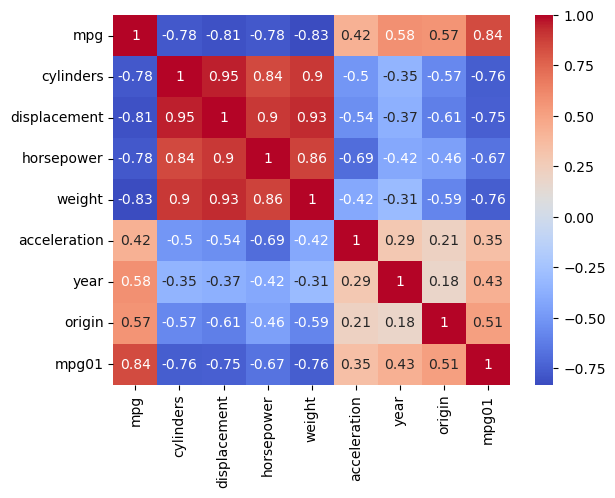

In [21]:
# b)
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")

In [17]:
data.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531,0.500000
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518,0.500639
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,0.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,0.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.500000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,1.000000


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   mpg01         392 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 38.7+ KB


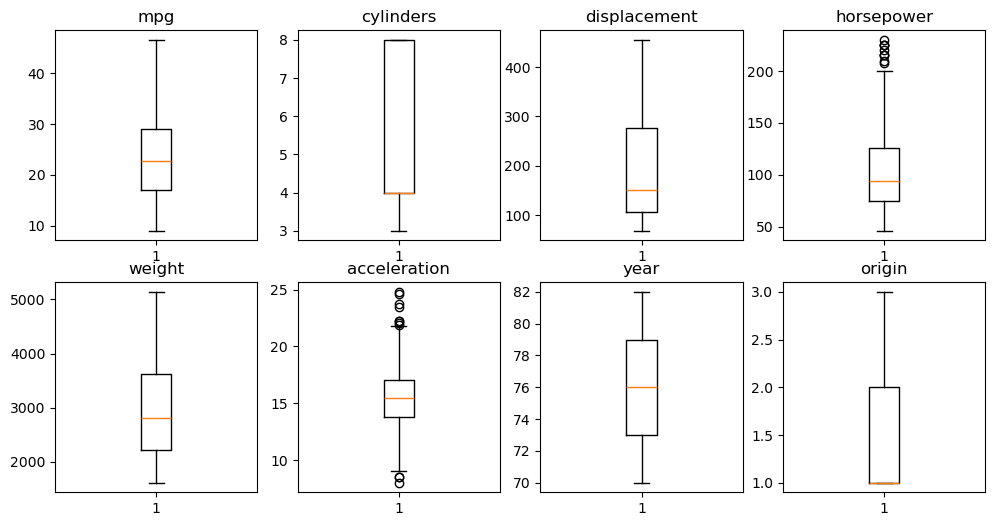

In [28]:
X = data.iloc[:, 0:8]
y = data["mpg01"]

cols = X.columns

fig, axes = plt.subplots(2,4, figsize=(12,6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(X[col])
    axes[i].set_title(col)


plt.show()

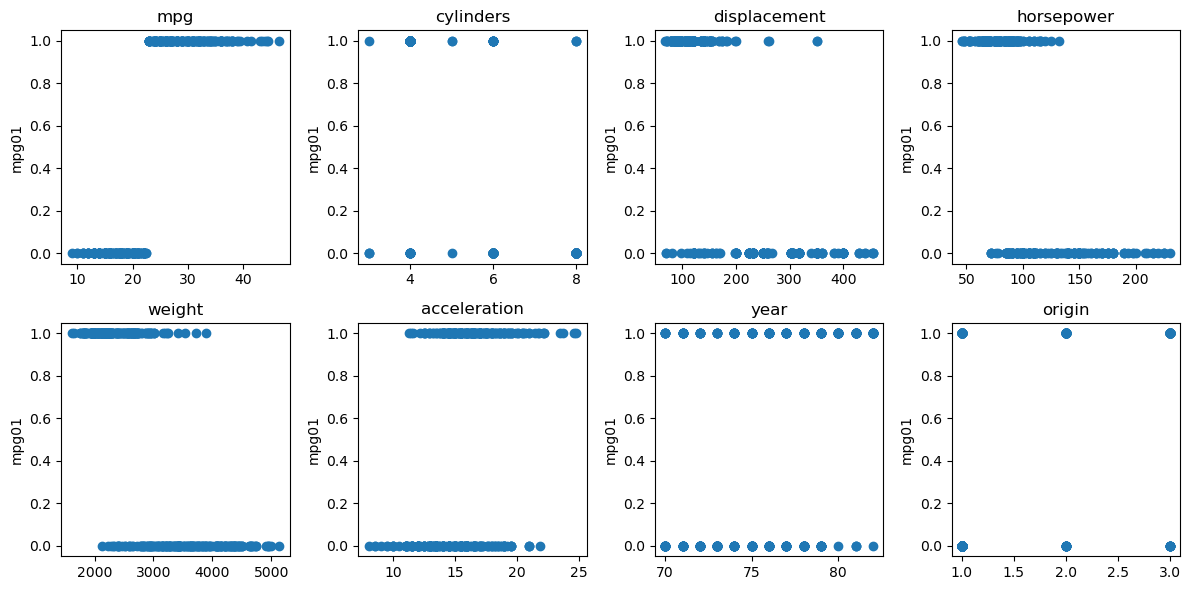

In [32]:
X = data.iloc[:, 0:8]
y = data["mpg01"]

cols = X.columns

fig, axes = plt.subplots(2,4, figsize=(12,6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].scatter(X[col], y)
    axes[i].set_ylabel("mpg01")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [79]:
X = data.iloc[:, 0:5]
y = data["mpg01"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2 ,shuffle=True)


In [80]:
lda = LDA()

lda.fit(X_train, Y_train)
res = lda.predict(X_test)

print(accuracy_score(res, Y_test))
confusion_table(res, Y_test)

0.9493670886075949


Truth,0,1
Predicted,,
0,39,0
1,4,36


In [81]:
qda = QDA()
qda.fit(X_train, Y_train)
res = qda.predict(X_test)
print(accuracy_score(res, Y_test))
confusion_table(res, Y_test)

0.9620253164556962


Truth,0,1
Predicted,,
0,40,0
1,3,36


In [83]:
Logr = LogisticRegression()
Logr.fit(X_train, Y_train)
res = Logr.predict(X_test)
print(accuracy_score(res, Y_test))
confusion_table(res, Y_test)

0.9873417721518988


C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Truth,0,1
Predicted,,
0,42,0
1,1,36


In [84]:
NB = GaussianNB()
NB.fit(X_train, Y_train)
res = NB.predict(X_test)
print(accuracy_score(res, Y_test))
confusion_table(res, Y_test)

0.9240506329113924


Truth,0,1
Predicted,,
0,37,0
1,6,36


In [87]:
PARAMS = [1,5,10,50,100]

for i in range(len(PARAMS)):  
    NB = KNeighborsClassifier(n_neighbors=PARAMS[i])
    NB.fit(X_train, Y_train)
    res = NB.predict(X_test)
    print(accuracy_score(res, Y_test))
    confusion_table(res, Y_test)

# really confusing

0.8860759493670886
0.9240506329113924
0.9367088607594937
0.9113924050632911
0.9367088607594937
